In [1]:
import os
import re
import math
import ast

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay,
    brier_score_loss,
)
from sklearn.calibration import CalibrationDisplay

if "__file__" in globals():
    BASE_DIR = os.path.dirname(os.path.abspath(__file__))
else:
    BASE_DIR = os.getcwd()

EVENTS_DIR = os.path.join(BASE_DIR, "events")


TOP5_COMP_IDS = [2, 7, 9, 11, 12]

PLAYER_ID_COL   = "player_id"
PLAYER_NAME_COL = "player_name"
SHOT_XG_COL     = "shot_statsbomb_xg"
TYPE_COL        = "type"
SHOT_OUTCOME_COL = "shot_outcome"
LOCATION_COL    = "location"
UNDER_PRESSURE_COL = "under_pressure"

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

GOAL_X = 120.0
GOAL_Y = 40.0

PITCH_X_MIN, PITCH_X_MAX = 0, 120
PITCH_Y_MIN, PITCH_Y_MAX = 0, 80


def draw_pitch(ax=None, color="#000000", lw=1):
    """Draw a StatsBomb-style 120x80 pitch."""
    if ax is None:
        ax = plt.gca()

    # Pitch Outline & Centre Line
    ax.plot([0, 120], [0, 0], color=color, lw=lw)
    ax.plot([0, 120], [80, 80], color=color, lw=lw)
    ax.plot([0, 0], [0, 80], color=color, lw=lw)
    ax.plot([120, 120], [0, 80], color=color, lw=lw)
    ax.plot([60, 60], [0, 80], color=color, lw=lw)

    # Left Penalty Area
    ax.plot([18, 18], [18, 62], color=color, lw=lw)
    ax.plot([0, 18], [18, 18], color=color, lw=lw)
    ax.plot([0, 18], [62, 62], color=color, lw=lw)

    # Right Penalty Area
    ax.plot([102, 102], [18, 62], color=color, lw=lw)
    ax.plot([102, 120], [18, 18], color=color, lw=lw)
    ax.plot([102, 120], [62, 62], color=color, lw=lw)

    # Left 6-yard Box
    ax.plot([6, 6], [30, 50], color=color, lw=lw)
    ax.plot([0, 6], [30, 30], color=color, lw=lw)
    ax.plot([0, 6], [50, 50], color=color, lw=lw)

    # Right 6-yard Box
    ax.plot([114, 114], [30, 50], color=color, lw=lw)
    ax.plot([114, 120], [30, 30], color=color, lw=lw)
    ax.plot([114, 120], [50, 50], color=color, lw=lw)

    # Center Circle
    cc = plt.Circle((60, 40), 10, color=color, fill=False, lw=lw)
    ax.add_patch(cc)

    # Penalty Spots & Center Spot
    ax.plot(12, 40, marker='o', color=color, ms=3)
    ax.plot(108, 40, marker='o', color=color, ms=3)
    ax.plot(60, 40, marker='o', color=color, ms=3)

    # Goal Frames
    ax.plot([-1, -1], [36, 44], color=color, lw=lw)
    ax.plot([121, 121], [36, 44], color=color, lw=lw)

    ax.set_xlim(-5, 125)
    ax.set_ylim(-5, 85)
    ax.set_aspect('equal')
    ax.axis("off")

    return ax


def get_type_name(x):
    return x.get("name") if isinstance(x, dict) else x


def get_outcome_name(x):
    return x.get("name") if isinstance(x, dict) else x


def get_body_part_name(x):
    return x.get("name") if isinstance(x, dict) else x


def get_pass_height_name(x):
    return x.get("name") if isinstance(x, dict) else x


def get_player_name(x):
    if isinstance(x, dict):
        return x.get("name")
    if isinstance(x, str):
        return x
    return None


def get_x(loc):
    try:
        if isinstance(loc, (list, tuple, np.ndarray)) and len(loc) >= 1:
            return float(loc[0])
    except Exception:
        pass
    return np.nan


def get_y(loc):
    try:
        if isinstance(loc, (list, tuple, np.ndarray)) and len(loc) >= 2:
            return float(loc[1])
    except Exception:
        pass
    return np.nan


In [2]:
shots_list = []
passes_list = []

parquet_files = [f for f in os.listdir(EVENTS_DIR) if f.endswith(".parquet")]
print(f"Found {len(parquet_files)} parquet files.")

for fname in parquet_files:
    fpath = os.path.join(EVENTS_DIR, fname)
    df = pd.read_parquet(fpath)

    if "competition_id" not in df.columns:
        continue

    df = df[df["competition_id"].isin(TOP5_COMP_IDS)].copy()
    if df.empty:
        continue

    df["type_name"] = df[TYPE_COL].apply(get_type_name)
    df["shot_outcome_name"] = df[SHOT_OUTCOME_COL].apply(get_outcome_name)

    df_passes = df[df["type_name"] == "Pass"].copy()
    if not df_passes.empty:
        passes_list.append(df_passes[["id", "location", "pass_height"]])

    df_shots = df[df["type_name"] == "Shot"].copy()
    if df_shots.empty:
        continue

    shots_list.append(df_shots)
    print(f"Loaded {len(df_shots)} shots from {fname}")

shots = pd.concat(shots_list, ignore_index=True)
print("Total shots across all Top 5 leagues:", len(shots))
print("Columns:", len(shots.columns))

# Merge pass origin into shots
if passes_list:
    passes = pd.concat(passes_list, ignore_index=True)
    passes = passes.rename(columns={"id": "pass_id", "location": "pass_start_location"})
else:
    passes = pd.DataFrame(columns=["pass_id", "pass_start_location", "pass_height"])

print("Total passes collected:", len(passes))

if "shot_key_pass_id" in shots.columns:
    shots = shots.merge(
        passes,
        how="left",
        left_on="shot_key_pass_id",
        right_on="pass_id",
    )
    shots.drop(columns=["pass_id"], inplace=True)

    pass_height_cols = [c for c in shots.columns if c.startswith("pass_height")]

    if "pass_height_y" in pass_height_cols:
        shots["pass_height"] = shots["pass_height_y"]
    elif "pass_height" not in shots.columns:
        shots["pass_height"] = np.nan

    cols_to_drop = [c for c in pass_height_cols if c != "pass_height"]
    if cols_to_drop:
        shots.drop(columns=cols_to_drop, inplace=True)
else:
    shots["pass_start_location"] = np.nan
    shots["pass_height"] = np.nan

# Player names & goal flag
shots = shots.copy()
shots.drop(columns=[PLAYER_NAME_COL], errors="ignore", inplace=True)

shots[PLAYER_NAME_COL] = shots["player"].apply(get_player_name)
shots[PLAYER_NAME_COL] = shots[PLAYER_NAME_COL].fillna("Unknown")

shots["is_goal"] = (shots["shot_outcome_name"] == "Goal").astype(int)

print("Total shots:", len(shots))
print("Total goals:", shots["is_goal"].sum())
print("Goal rate:", shots["is_goal"].mean())

display(shots[[PLAYER_ID_COL, PLAYER_NAME_COL, "shot_outcome_name", "is_goal"]].head())


Found 75 parquet files.
Loaded 851 shots from events_comp7_season235.parquet
Loaded 8814 shots from events_comp7_season27.parquet
Loaded 681 shots from events_comp7_season108.parquet
Loaded 810 shots from events_comp11_season25.parquet
Loaded 729 shots from events_comp11_season40.parquet
Loaded 681 shots from events_comp11_season39.parquet
Loaded 839 shots from events_comp11_season90.parquet
Loaded 882 shots from events_comp11_season2.parquet
Loaded 739 shots from events_comp11_season22.parquet
Loaded 873 shots from events_comp11_season23.parquet
Loaded 28 shots from events_comp11_season278.parquet
Loaded 433 shots from events_comp11_season38.parquet
Loaded 765 shots from events_comp11_season41.parquet
Loaded 9998 shots from events_comp12_season27.parquet
Loaded 158 shots from events_comp11_season37.parquet
Loaded 9168 shots from events_comp11_season27.parquet
Loaded 887 shots from events_comp11_season4.parquet
Loaded 7831 shots from events_comp9_season27.parquet
Loaded 971 shots from 

,player_id,player_name,shot_outcome_name,is_goal
0,32481.0,Muhammed Cham Saracevic,Wayward,0
1,50429.0,Hugo Ekitike,Blocked,0
2,7626.0,Johan Gastien,Wayward,0
3,5503.0,Lionel Andrés Messi Cuccittini,Saved,0
4,3009.0,Kylian Mbappé Lottin,Saved,0


In [3]:
shots = shots[shots[PLAYER_ID_COL].notna()].copy()
group = shots.groupby(PLAYER_ID_COL)

player_hist = group.agg(
    player_name=(
        PLAYER_NAME_COL,
        lambda x: x.mode().iloc[0] if len(x.mode()) > 0 else x.iloc[0]
    ),
    player_shots_total=("is_goal", "count"),
    player_goals_total=("is_goal", "sum"),
    player_xg_sum=(SHOT_XG_COL, "sum"),
    player_xg_mean=(SHOT_XG_COL, "mean"),
).reset_index()

player_hist["player_conv_rate"] = (
    player_hist["player_goals_total"] / player_hist["player_shots_total"]
)
player_hist["player_goals_minus_xg"] = (
    player_hist["player_goals_total"] - player_hist["player_xg_sum"]
)

print("Player history sample:")
display(player_hist.head())

player_hist_to_merge = player_hist.drop(columns=["player_name"])

shots = shots.merge(
    player_hist_to_merge,
    on=PLAYER_ID_COL,
    how="left",
)

for col in ["player_xg_mean", "player_conv_rate", "player_goals_minus_xg"]:
    shots[col] = shots[col].fillna(shots[col].mean())

print("Shots after merging player history:", len(shots))
display(
    shots[
        [
            PLAYER_ID_COL,
            "player_name",
            "player_shots_total",
            "player_goals_total",
            "player_conv_rate",
            "player_xg_mean",
            "player_goals_minus_xg",
        ]
    ].head()
)


Player history sample:


,player_id,player_name,player_shots_total,player_goals_total,player_xg_sum,player_xg_mean,player_conv_rate,player_goals_minus_xg
0,2935.0,Nordi Mukiele Mulere,7,0,0.813189,0.116170,0.000000,-0.813189
1,2936.0,Christophe Kerbrat,4,0,0.201584,0.050396,0.000000,-0.201584
2,2943.0,Lucas Deaux,4,0,0.284798,0.071200,0.000000,-0.284798
3,2944.0,Benjamin Corgnet,11,1,1.119128,0.101739,0.090909,-0.119128
4,2946.0,Frédéric Guilbert,13,0,0.401484,0.030883,0.000000,-0.401484


Shots after merging player history: 61173


,player_id,player_name,player_shots_total,player_goals_total,player_conv_rate,player_xg_mean,player_goals_minus_xg
0,32481.0,Muhammed Cham Saracevic,5,0,0.000000,0.104780,-0.523902
1,50429.0,Hugo Ekitike,24,3,0.125000,0.120633,0.104807
2,7626.0,Johan Gastien,4,1,0.250000,0.167317,0.330733
3,5503.0,Lionel Andrés Messi Cuccittini,2574,496,0.192696,0.134913,148.735158
4,3009.0,Kylian Mbappé Lottin,227,50,0.220264,0.171483,11.073268


In [4]:
shots_geo = shots.copy()

print("Sample of LOCATION_COL before split:")
print(shots_geo[LOCATION_COL].head())
print("\nValue counts for LOCATION_COL types:")
print(shots_geo[LOCATION_COL].apply(type).value_counts())
print("Number of NaNs in LOCATION_COL:", shots_geo[LOCATION_COL].isna().sum())

# (Re)build location-based features
for col in ["shot_x", "shot_y", "distance_to_goal", "shot_angle"]:
    if col in shots_geo.columns:
        shots_geo.drop(columns=[col], inplace=True)

shots_geo["shot_x"] = shots_geo[LOCATION_COL].apply(get_x)
shots_geo["shot_y"] = shots_geo[LOCATION_COL].apply(get_y)

print("Non-nulls in shot_x:", shots_geo["shot_x"].notna().sum())
print("Non-nulls in shot_y:", shots_geo["shot_y"].notna().sum())

dx = GOAL_X - shots_geo["shot_x"]
dy = shots_geo["shot_y"] - GOAL_Y

shots_geo["distance_to_goal"] = np.sqrt(dx**2 + dy**2)
shots_geo["shot_angle"] = np.arctan2(7.32 / 2, shots_geo["distance_to_goal"]) * 2

shots_geo["under_pressure_num"] = (
    shots_geo[UNDER_PRESSURE_COL].fillna(False).astype(int)
)

# Body part and header flag
shots_geo["shot_body_part_name"] = shots_geo["shot_body_part"].apply(get_body_part_name)

# Foot counts per player
foot_counts = (
    shots_geo
    .loc[shots_geo["shot_body_part_name"].isin(["Left Foot", "Right Foot"])]
    .groupby(["player_id", "shot_body_part_name"])
    .size()
    .unstack(fill_value=0)
)

for col in ["Left Foot", "Right Foot"]:
    if col not in foot_counts.columns:
        foot_counts[col] = 0

def infer_preferred_foot(row):
    left = row["Left Foot"]
    right = row["Right Foot"]
    if left == 0 and right == 0:
        return "Right"   # default assumption
    return "Left" if left > right else "Right"

foot_counts["preferred_foot"] = foot_counts.apply(infer_preferred_foot, axis=1)
player_pref_foot = foot_counts["preferred_foot"].reset_index()

shots_geo = shots_geo.merge(player_pref_foot, on="player_id", how="left")

def get_shot_foot_used(x):
    if x == "Left Foot":
        return "Left"
    if x == "Right Foot":
        return "Right"
    return "None"

shots_geo["shot_foot_used"] = shots_geo["shot_body_part_name"].apply(get_shot_foot_used)
is_foot_shot = shots_geo["shot_foot_used"].isin(["Left", "Right"])

shots_geo["is_strong_foot"] = (
    is_foot_shot & (shots_geo["shot_foot_used"] == shots_geo["preferred_foot"])
).astype(int)

shots_geo["is_weak_foot"] = (
    is_foot_shot & (shots_geo["shot_foot_used"] != shots_geo["preferred_foot"])
).astype(int)

shots_geo["weak_foot_distance"] = shots_geo["distance_to_goal"] * shots_geo["is_weak_foot"]
shots_geo["weak_foot_angle"]    = shots_geo["shot_angle"] * shots_geo["is_weak_foot"]

shots_geo["strong_foot_distance"] = shots_geo["distance_to_goal"] * shots_geo["is_strong_foot"]
shots_geo["strong_foot_angle"]    = shots_geo["shot_angle"] * shots_geo["is_strong_foot"]

shots_geo["is_header"] = (shots_geo["shot_body_part_name"] == "Head").astype(int)

# Cross / aerial / box features
if "pass_cross" in shots_geo.columns:
    shots_geo["from_cross"] = shots_geo["pass_cross"].fillna(False).astype(int)
else:
    shots_geo["from_cross"] = 0

if "shot_aerial_won" in shots_geo.columns:
    shots_geo["won_aerial_duel"] = shots_geo["shot_aerial_won"].fillna(False).astype(int)
else:
    shots_geo["won_aerial_duel"] = 0

shots_geo["in_six_yard"] = (shots_geo["distance_to_goal"] <= 5.5).astype(int)
shots_geo["in_box"]      = (shots_geo["distance_to_goal"] <= 18.0).astype(int)

shots_geo["header_distance"]   = shots_geo["distance_to_goal"] * shots_geo["is_header"]
shots_geo["header_angle"]      = shots_geo["shot_angle"] * shots_geo["is_header"]
shots_geo["header_dist_angle"] = (
    shots_geo["distance_to_goal"] * shots_geo["shot_angle"] * shots_geo["is_header"]
)
shots_geo["header_cross"]      = shots_geo["is_header"] * shots_geo["from_cross"]

# Incoming pass geometry
if "pass_start_location" in shots_geo.columns:
    shots_geo["pass_start_x"] = shots_geo["pass_start_location"].apply(get_x)
    shots_geo["pass_start_y"] = shots_geo["pass_start_location"].apply(get_y)
else:
    shots_geo["pass_start_x"] = np.nan
    shots_geo["pass_start_y"] = np.nan

shots_geo["pass_start_x"] = shots_geo["pass_start_x"].astype(float)
shots_geo["pass_start_y"] = shots_geo["pass_start_y"].astype(float)

shots_geo["incoming_pass_angle"] = np.arctan2(
    GOAL_Y - shots_geo["pass_start_y"],
    GOAL_X - shots_geo["pass_start_x"],
)
shots_geo["incoming_pass_angle"] = shots_geo["incoming_pass_angle"].replace(
    [np.inf, -np.inf], 0
).fillna(0.0)

shots_geo["header_incoming_angle"] = (
    shots_geo["incoming_pass_angle"] *
    shots_geo["is_header"] *
    shots_geo["from_cross"]
)

# Pass height
if "pass_height" in shots_geo.columns:
    shots_geo["pass_height_name"] = shots_geo["pass_height"].apply(get_pass_height_name)
else:
    shots_geo["pass_height_name"] = ""

shots_geo["high_cross_ball"]   = (shots_geo["pass_height_name"] == "High Pass").astype(int)
shots_geo["low_cross_ball"]    = (shots_geo["pass_height_name"] == "Low Pass").astype(int)
shots_geo["ground_cross_ball"] = (shots_geo["pass_height_name"] == "Ground Pass").astype(int)
shots_geo["header_highball"]   = shots_geo["high_cross_ball"] * shots_geo["is_header"]


Sample of LOCATION_COL before split:
0     [97.1, 29.9]
1    [107.7, 49.1]
2     [95.2, 42.6]
3    [100.5, 37.3]
4    [112.9, 29.4]
Name: location, dtype: object

Value counts for LOCATION_COL types:
location
<class 'numpy.ndarray'>    61173
Name: count, dtype: int64
Number of NaNs in LOCATION_COL: 0
Non-nulls in shot_x: 61173
Non-nulls in shot_y: 61173


/tmp/ipython-input-3356490029.py:27: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  shots_geo[UNDER_PRESSURE_COL].fillna(False).astype(int)
/tmp/ipython-input-3356490029.py:86: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  shots_geo["from_cross"] = shots_geo["pass_cross"].fillna(False).astype(int)
/tmp/ipython-input-3356490029.py:91: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option(

In [5]:
base_numeric = [
    "shot_x",
    "distance_to_goal",
    "shot_angle",
    SHOT_XG_COL,
    "player_conv_rate",
    "player_xg_mean",
    "player_goals_minus_xg",
    "under_pressure_num",
]

header_numeric = [
    "is_header",
    "won_aerial_duel",
    "in_six_yard",
    "in_box",
    "header_distance",
    "header_angle",
    "header_dist_angle",
]

foot_numeric = [
    "is_strong_foot",
    "is_weak_foot",
    "weak_foot_distance",
    "weak_foot_angle",
    "strong_foot_distance",
    "strong_foot_angle",
]

required_numeric = base_numeric + header_numeric + foot_numeric

print("Numeric features:", required_numeric)

before = len(shots_geo)
shots_geo = shots_geo.dropna(subset=required_numeric + ["is_goal"]).copy()
after = len(shots_geo)

print("Shots before filtering:", before)
print("Shots after filtering:", after)
print("Positive class rate (goals):", shots_geo["is_goal"].mean())

X = shots_geo[required_numeric]
y = shots_geo["is_goal"]
print("Final X shape:", X.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Train size:", X_train.shape, "Test size:", X_test.shape)
print("Train goal rate:", y_train.mean())
print("Test goal rate:", y_test.mean())


Numeric features: ['shot_x', 'distance_to_goal', 'shot_angle', 'shot_statsbomb_xg', 'player_conv_rate', 'player_xg_mean', 'player_goals_minus_xg', 'under_pressure_num', 'is_header', 'won_aerial_duel', 'in_six_yard', 'in_box', 'header_distance', 'header_angle', 'header_dist_angle', 'is_strong_foot', 'is_weak_foot', 'weak_foot_distance', 'weak_foot_angle', 'strong_foot_distance', 'strong_foot_angle']
Shots before filtering: 61173
Shots after filtering: 61173
Positive class rate (goals): 0.11029375704967878
Final X shape: (61173, 21)
Train size: (48938, 21) Test size: (12235, 21)
Train goal rate: 0.1103028321549716
Test goal rate: 0.11025745811197385


In [6]:
log_reg = LogisticRegression(
    random_state=RANDOM_STATE,
    max_iter=1000,
    n_jobs=-1,
)

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=5,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

hgb = HistGradientBoostingClassifier(
    learning_rate=0.03,
    max_iter=400,
    max_depth=3,
    l2_regularization=0.1,
)

models = {
    "Logistic Regression": log_reg,
    "Random Forest": rf,
    "HistGradientBoosting": hgb,
}

fitted_models = {}
for name, model in models.items():
    print(f"\n=== Training {name} ===")
    model.fit(X_train, y_train)
    fitted_models[name] = model

feature_names = X_train.columns.tolist()

def get_importances(model):
    if hasattr(model, "coef_"):  # Logistic Regression
        return pd.Series(model.coef_[0], index=feature_names).abs().sort_values(ascending=False)
    elif hasattr(model, "feature_importances_"):  # RF + HGB
        return pd.Series(model.feature_importances_, index=feature_names).sort_values(ascending=False)
    else:
        return None

logreg_imp = get_importances(fitted_models["Logistic Regression"])
rf_imp     = get_importances(fitted_models["Random Forest"])
hgb_imp    = get_importances(fitted_models["HistGradientBoosting"])

print("\n=== Logistic Regression Feature Importance ===")
display(logreg_imp)

print("\n=== Random Forest Feature Importance ===")
display(rf_imp)

print("\n=== HistGradientBoosting Feature Importance ===")
display(hgb_imp)

importance_df = pd.DataFrame({
    "LogReg": logreg_imp,
    "RF": rf_imp,
    "HGB": hgb_imp,
})
importance_df["average_rank"] = importance_df.rank(ascending=False).mean(axis=1)

print("\n=== Combined Feature Ranking (Lower rank = more important) ===")
display(importance_df.sort_values("average_rank"))



=== Training Logistic Regression ===

=== Training Random Forest ===

=== Training HistGradientBoosting ===

=== Logistic Regression Feature Importance ===


,0
player_conv_rate,9.762721
player_xg_mean,8.013460
shot_statsbomb_xg,5.279092
shot_angle,0.589612
is_weak_foot,0.535101
won_aerial_duel,0.443388
weak_foot_angle,0.405462
header_angle,0.174383
header_dist_angle,0.142107
header_distance,0.135676



=== Random Forest Feature Importance ===


,0
shot_statsbomb_xg,0.289054
player_conv_rate,0.100152
player_goals_minus_xg,0.086859
distance_to_goal,0.082475
shot_angle,0.081666
strong_foot_angle,0.078586
shot_x,0.072901
player_xg_mean,0.064106
strong_foot_distance,0.046214
header_dist_angle,0.015245



=== HistGradientBoosting Feature Importance ===


None


=== Combined Feature Ranking (Lower rank = more important) ===


,LogReg,RF,HGB,average_rank
player_conv_rate,9.762721,0.100152,None,1.5
shot_statsbomb_xg,5.279092,0.289054,None,2.0
shot_angle,0.589612,0.081666,None,4.5
player_xg_mean,8.013460,0.064106,None,5.0
distance_to_goal,0.092978,0.082475,None,7.5
header_dist_angle,0.142107,0.015245,None,9.5
weak_foot_angle,0.405462,0.013739,None,9.5
header_angle,0.174383,0.011861,None,10.5
header_distance,0.135676,0.013841,None,10.5
strong_foot_angle,0.031702,0.078586,None,11.0


In [7]:
THRESHOLD = 0.27  # decision threshold for "Goal"

def evaluate_model(name, model, X_train, y_train, X_test, y_test, threshold=THRESHOLD):
    print(f"\n=== {name} ===")

    y_train_proba = model.predict_proba(X_train)[:, 1]
    y_test_proba  = model.predict_proba(X_test)[:, 1]

    y_train_pred = (y_train_proba >= threshold).astype(int)
    y_test_pred  = (y_test_proba  >= threshold).astype(int)

    metrics = {
        "threshold": threshold,
        "acc_train": accuracy_score(y_train, y_train_pred),
        "acc_test":  accuracy_score(y_test,  y_test_pred),
        "prec_test": precision_score(y_test, y_test_pred, zero_division=0),
        "rec_test":  recall_score(y_test,  y_test_pred, zero_division=0),
        "f1_test":   f1_score(y_test,      y_test_pred, zero_division=0),
        "roc_auc_train": roc_auc_score(y_train, y_train_proba),
        "roc_auc_test":  roc_auc_score(y_test,  y_test_proba),
    }

    for k, v in metrics.items():
        print(f"{k:>15}: {v:.4f}")

    print("\nClassification report (test):")
    print(classification_report(y_test, y_test_pred, digits=3))

    return metrics

all_metrics = {}
for name, model in fitted_models.items():
    all_metrics[name] = evaluate_model(
        name, model, X_train, y_train, X_test, y_test
    )

pd.DataFrame(all_metrics).T



=== Logistic Regression ===
      threshold: 0.2700
      acc_train: 0.8967
       acc_test: 0.8946
      prec_test: 0.5255
       rec_test: 0.4514
        f1_test: 0.4856
  roc_auc_train: 0.8562
   roc_auc_test: 0.8520

Classification report (test):
              precision    recall  f1-score   support

           0      0.933     0.949     0.941     10886
           1      0.525     0.451     0.486      1349

    accuracy                          0.895     12235
   macro avg      0.729     0.700     0.713     12235
weighted avg      0.888     0.895     0.891     12235


=== Random Forest ===
      threshold: 0.2700
      acc_train: 0.9441
       acc_test: 0.8812
      prec_test: 0.4645
       rec_test: 0.5093
        f1_test: 0.4859
  roc_auc_train: 0.9798
   roc_auc_test: 0.8500

Classification report (test):
              precision    recall  f1-score   support

           0      0.938     0.927     0.933     10886
           1      0.465     0.509     0.486      1349

    accurac

,threshold,acc_train,acc_test,prec_test,rec_test,f1_test,roc_auc_train,roc_auc_test
Logistic Regression,0.27,0.896706,0.894565,0.525453,0.451446,0.485646,0.856179,0.852010
Random Forest,0.27,0.944133,0.881161,0.464503,0.509266,0.485856,0.979754,0.850048
HistGradientBoosting,0.27,0.891741,0.885738,0.482807,0.510007,0.496035,0.876644,0.863940


test_results shape: (12235, 169)


,player_name,y_true,y_pred,proba
1762,Benjamin Jeannot,0,0,0.096377
33793,Aritz Elustondo Irribaria,1,1,0.294302
7545,Hatem Ben Arfa,1,0,0.065879
15803,Francesc Fàbregas i Soler,1,1,0.317648
32509,Fabián Ariel Orellana Valenzuela,0,0,0.037703


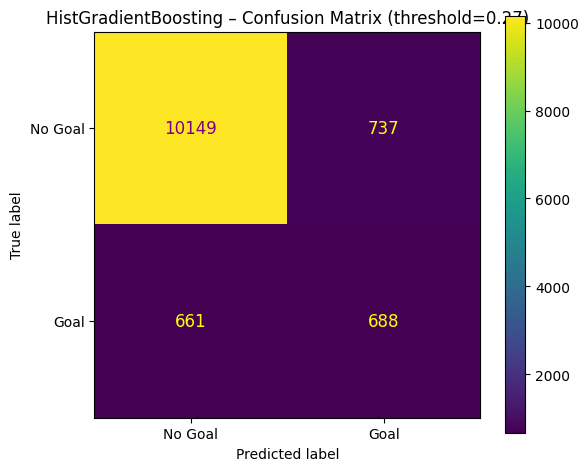

In [8]:
best_model_name = "HistGradientBoosting"
best_model = fitted_models[best_model_name]

y_test_proba = best_model.predict_proba(X_test)[:, 1]
y_test_pred  = (y_test_proba >= THRESHOLD).astype(int)

# Build test_results dataframe
test_results = shots_geo.loc[X_test.index].copy()
test_results["y_true"] = y_test
test_results["y_pred"] = y_test_pred
test_results["proba"]  = y_test_proba
test_results["error"]  = test_results["proba"] - test_results["y_true"]

PLAYER_NAME_COL_SAFE = "player_name" if "player_name" in test_results.columns else "player"

print("test_results shape:", test_results.shape)
display(test_results[[PLAYER_NAME_COL_SAFE, "y_true", "y_pred", "proba"]].head())

# Confusion matrix @ threshold = THRESHOLD
cm = confusion_matrix(y_test, y_test_pred)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, interpolation="nearest", cmap="viridis")
plt.colorbar(im, ax=ax)

classes = ["No Goal", "Goal"]
ax.set(
    xticks=np.arange(len(classes)),
    yticks=np.arange(len(classes)),
    xticklabels=classes,
    yticklabels=classes,
    ylabel="True label",
    xlabel="Predicted label",
    title=f"{best_model_name} – Confusion Matrix (threshold={THRESHOLD:.2f})",
)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        text_color = "purple" if (i, j) == (0, 0) else "yellow"
        ax.text(j, i, format(cm[i, j], "d"),
                ha="center", va="center",
                color=text_color, fontsize=12)

plt.tight_layout()
plt.show()


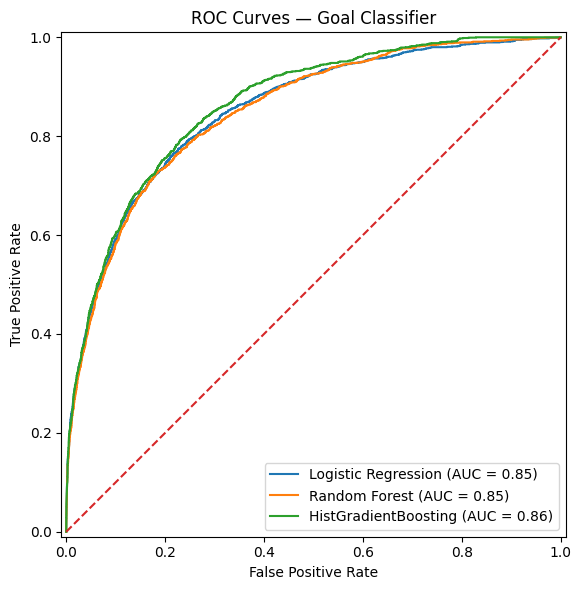

In [9]:
fig, ax = plt.subplots(figsize=(6, 6))

for name, model in models.items():
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        scores = model.decision_function(X_test)
        y_proba = (scores - scores.min()) / (scores.max() - scores.min() + 1e-9)
    else:
        y_proba = model.predict(X_test).astype(float)

    RocCurveDisplay.from_predictions(
        y_test,
        y_proba,
        name=name,
        ax=ax,
    )

ax.plot([0, 1], [0, 1], linestyle="--")
ax.set_title("ROC Curves — Goal Classifier")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
plt.tight_layout()
plt.show()



=== Strong vs Weak vs Header vs Other – Test Metrics ===


,group,n_shots,goal_rate,acc,precision,recall,f1,roc_auc
0,Other body parts,34,0.294118,0.823529,0.642857,0.900000,0.750000,0.958333
1,Strong-foot (non-header),8266,0.108275,0.890394,0.494241,0.527374,0.510270,0.869625
2,Weak-foot (non-header),2039,0.112800,0.874939,0.454212,0.539130,0.493042,0.867574
3,All shots,12235,0.110257,0.885738,0.482807,0.510007,0.496035,0.863940
4,Headers,1896,0.112869,0.878165,0.453552,0.387850,0.418136,0.825639


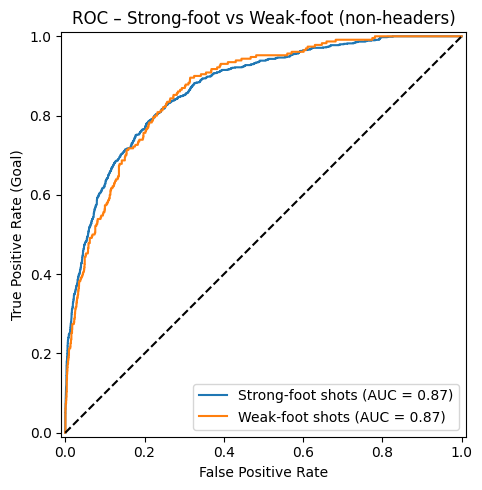

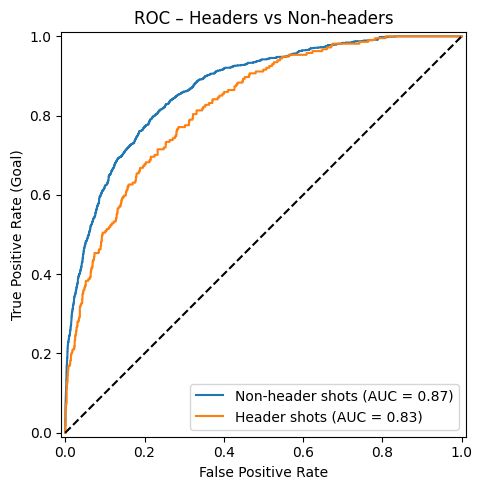

In [10]:
def subgroup_metrics(df, name):
    y_true = df["y_true"].values
    y_pred = df["y_pred"].values
    y_proba = df["proba"].values

    if len(np.unique(y_true)) < 2:
        auc = np.nan
    else:
        auc = roc_auc_score(y_true, y_proba)

    return {
        "group": name,
        "n_shots": len(df),
        "goal_rate": y_true.mean(),
        "acc": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": auc,
    }

all_test = test_results.copy()

for col in ["is_header", "is_strong_foot", "is_weak_foot"]:
    if col not in all_test.columns:
        raise ValueError(f"Column '{col}' missing from test_results – did you run all feature-engineering cells?")

mask_header      = all_test["is_header"] == 1
mask_non_header  = all_test["is_header"] == 0
mask_strong_foot = (all_test["is_strong_foot"] == 1) & mask_non_header
mask_weak_foot   = (all_test["is_weak_foot"] == 1) & mask_non_header
mask_other_body  = mask_non_header & (all_test["is_strong_foot"] == 0) & (all_test["is_weak_foot"] == 0)

groups = [
    ("All shots", all_test),
    ("Strong-foot (non-header)", all_test[mask_strong_foot]),
    ("Weak-foot (non-header)", all_test[mask_weak_foot]),
    ("Headers", all_test[mask_header]),
    ("Other body parts", all_test[mask_other_body]),
]

rows = [subgroup_metrics(df, name) for name, df in groups if len(df) > 0]
subgroup_table = pd.DataFrame(rows)

print("\n=== Strong vs Weak vs Header vs Other – Test Metrics ===")
display(subgroup_table.sort_values("roc_auc", ascending=False).reset_index(drop=True))

# ROC strong vs weak foot (non-headers)
foot_shots = all_test[mask_non_header & (all_test["is_strong_foot"] + all_test["is_weak_foot"] > 0)].copy()
strong = foot_shots[foot_shots["is_strong_foot"] == 1]
weak   = foot_shots[foot_shots["is_weak_foot"] == 1]

plt.figure(figsize=(6, 5))

def plot_group_roc(df, label):
    if len(df) < 10 or len(np.unique(df["y_true"])) < 2:
        print(f"Skipping ROC for {label} (not enough positive/negative examples)")
        return
    RocCurveDisplay.from_predictions(df["y_true"], df["proba"], name=label, ax=plt.gca())

plot_group_roc(strong, "Strong-foot shots")
plot_group_roc(weak,   "Weak-foot shots")

plt.plot([0, 1], [0, 1], "k--")
plt.title("ROC – Strong-foot vs Weak-foot (non-headers)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Goal)")
plt.legend()
plt.tight_layout()
plt.show()

# ROC headers vs non-headers
headers    = all_test[mask_header].copy()
nonheaders = all_test[mask_non_header].copy()

plt.figure(figsize=(6, 5))
plot_group_roc(nonheaders, "Non-header shots")
plot_group_roc(headers,    "Header shots")
plt.plot([0, 1], [0, 1], "k--")
plt.title("ROC – Headers vs Non-headers")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Goal)")
plt.legend()
plt.tight_layout()
plt.show()


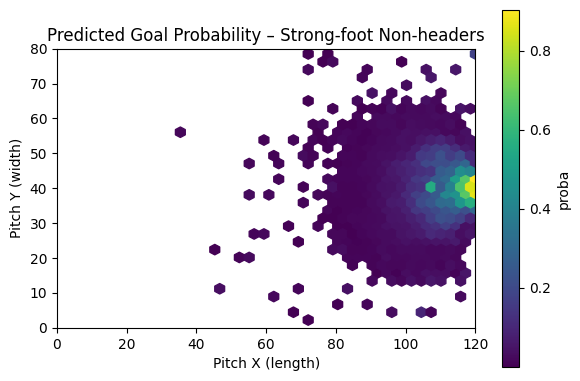

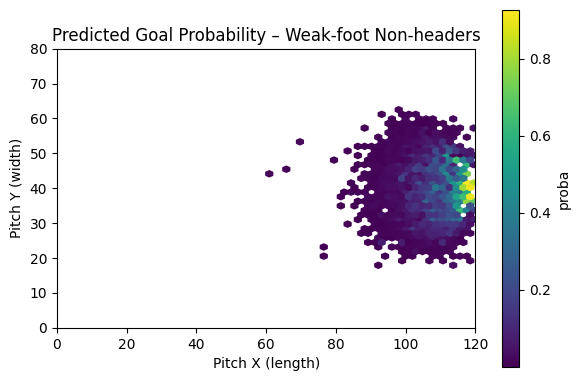

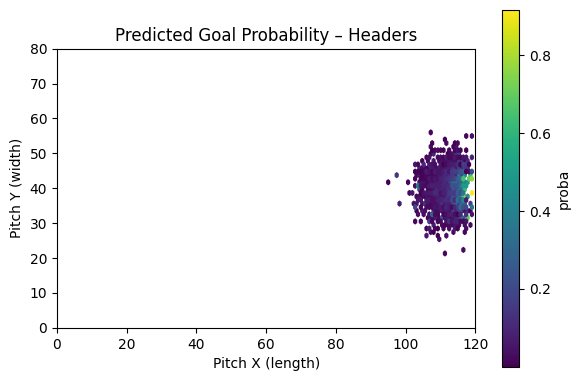

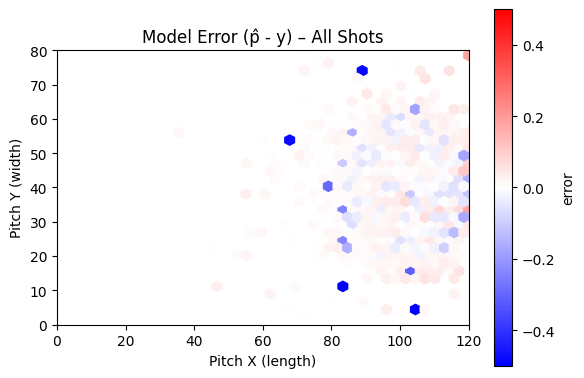

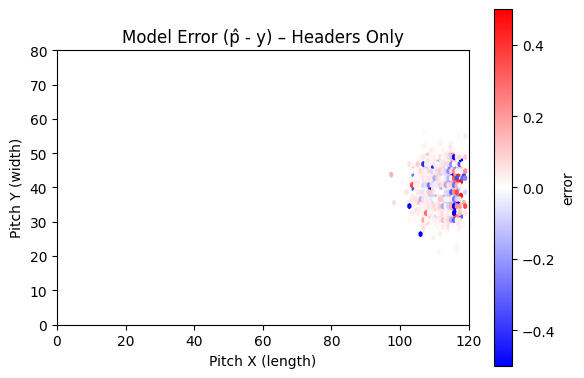

False negatives (missed goals): 661
False positives (imagined goals): 737


,match_id,player_name,minute,shot_x,shot_y,distance_to_goal,shot_angle,shot_statsbomb_xg,under_pressure_num,shot_type,shot_body_part,shot_outcome_name,proba,y_true,y_pred
13294,3773547,Martin Braithwaite Christensen,28,116.6,39.0,3.544009,1.602995,0.383430,0,Open Play,Other,Goal,0.234704,1,0
46988,266916,Gerard Piqué Bernabéu,48,116.7,38.3,3.712142,1.556651,0.239269,0,Open Play,Right Foot,Goal,0.182785,1,0
39583,3890485,Mathew Leckie,55,115.9,39.8,4.104875,1.456335,0.266515,0,Open Play,Head,Goal,0.201788,1,0
26623,3878557,Luca Rigoni,7,115.5,39.7,4.509989,1.363466,0.263896,1,Open Play,Head,Goal,0.246121,1,0
32403,3825859,Youssef El-Arabi,21,115.3,41.4,4.904080,1.282280,0.216290,1,Open Play,Head,Goal,0.255367,1,0
9626,3829415,Giovanni-Guy Yann Sio,38,115.0,38.9,5.119570,1.241317,0.359476,0,Open Play,Head,Goal,0.225936,1,0
22979,3879686,José María Callejón Bueno,18,117.2,35.7,5.131277,1.239157,0.378521,0,Open Play,Head,Goal,0.262181,1,0
5601,3829513,Adrien Thomasson,60,115.3,37.5,5.323533,1.204593,0.367297,0,Open Play,Right Foot,Goal,0.246647,1,0
58169,3754332,Craig Dawson,72,114.8,41.4,5.385165,1.193868,0.108182,1,Open Play,Head,Goal,0.124631,1,0
8774,3829458,Martin Braithwaite Christensen,29,114.8,38.5,5.412024,1.189246,0.426015,0,Open Play,Right Foot,Goal,0.251774,1,0


,match_id,player_name,minute,shot_x,shot_y,distance_to_goal,shot_angle,shot_statsbomb_xg,under_pressure_num,shot_type,shot_body_part,shot_outcome_name,proba,y_true,y_pred
13102,3773523,Antoine Griezmann,54,117.6,40.0,2.400000,1.980796,0.919709,0,Open Play,Right Foot,Saved Off Target,0.949367,0,1
8549,3829471,Pablo Nascimento Castro,6,117.6,41.0,2.600000,1.906272,0.368959,0,Open Play,Head,Off T,0.396892,0,1
24481,3879614,Andrea Belotti,47,118.0,38.3,2.624881,1.897265,0.731154,0,Open Play,Right Foot,Saved,0.800547,0,1
30284,3825708,Charles Días Barbosa de Oliveira,88,118.1,42.1,2.831960,1.824523,0.492104,1,Open Play,Head,Saved,0.472176,0,1
39102,3890506,Peter Niemeyer,83,117.1,39.3,2.983287,1.773824,0.491212,0,Open Play,Left Foot,Saved to Post,0.490865,0,1
17816,3879837,Mauro Emanuel Icardi Rivero,42,117.0,39.7,3.014963,1.763469,0.568324,1,Open Play,Head,Off T,0.634875,0,1
7583,3829428,Andy Delort,44,117.9,37.6,3.189044,1.708105,0.534257,1,Open Play,Head,Off T,0.445965,0,1
53188,3754003,Daniel William John Ings,63,116.8,40.4,3.224903,1.697020,0.269155,0,Open Play,Head,Blocked,0.463727,0,1
9791,3802699,Marcos Aoás Corrêa,68,116.9,41.8,3.584690,1.591586,0.316715,1,Open Play,Head,Off T,0.385470,0,1
57509,3754289,Robert Huth,58,116.5,39.2,3.590265,1.590032,0.215264,0,Open Play,Head,Saved,0.332301,0,1


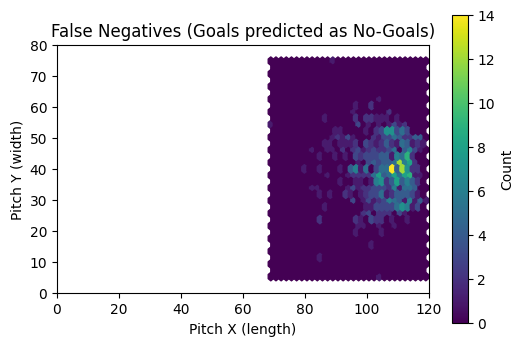

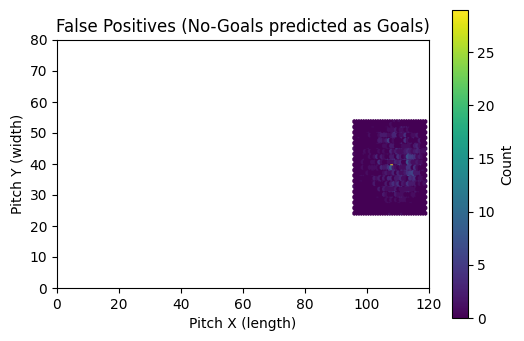

In [11]:
all_test = all_test.copy()
all_test["error"] = all_test["proba"] - all_test["y_true"]

def plot_hex_heatmap(df, value_col, title, vmin=None, vmax=None, cmap="viridis"):
    df = df.dropna(subset=["shot_x", "shot_y", value_col])
    if df.empty:
        print(f"No data for {title}")
        return

    plt.figure(figsize=(6, 4))
    hb = plt.hexbin(
        df["shot_x"],
        df["shot_y"],
        C=df[value_col],
        gridsize=30,
        reduce_C_function=np.mean,
        vmin=vmin,
        vmax=vmax,
        cmap=cmap,
    )
    plt.colorbar(hb, label=value_col)
    plt.xlim(0, 120)
    plt.ylim(0, 80)
    plt.xlabel("Pitch X (length)")
    plt.ylabel("Pitch Y (width)")
    plt.title(title)
    plt.gca().set_aspect("equal", adjustable="box")
    plt.tight_layout()
    plt.show()

strong_non_header = all_test[mask_strong_foot]
weak_non_header   = all_test[mask_weak_foot]
headers_only      = all_test[mask_header]

# Predicted goal probability heatmaps
plot_hex_heatmap(
    strong_non_header,
    value_col="proba",
    title="Predicted Goal Probability – Strong-foot Non-headers",
)

plot_hex_heatmap(
    weak_non_header,
    value_col="proba",
    title="Predicted Goal Probability – Weak-foot Non-headers",
)

plot_hex_heatmap(
    headers_only,
    value_col="proba",
    title="Predicted Goal Probability – Headers",
)

# Error heatmaps
plot_hex_heatmap(
    all_test,
    value_col="error",
    title="Model Error (p̂ - y) – All Shots",
    vmin=-0.5,
    vmax=0.5,
    cmap="bwr",
)

plot_hex_heatmap(
    headers_only,
    value_col="error",
    title="Model Error (p̂ - y) – Headers Only",
    vmin=-0.5,
    vmax=0.5,
    cmap="bwr",
)

# False negatives / positives
fn = test_results[(test_results["y_true"] == 1) & (test_results["y_pred"] == 0)].copy()
fp = test_results[(test_results["y_true"] == 0) & (test_results["y_pred"] == 1)].copy()

print("False negatives (missed goals):", len(fn))
print("False positives (imagined goals):", len(fp))

fn_sorted = fn.sort_values("distance_to_goal", ascending=True).copy()
fp_sorted = fp.sort_values("distance_to_goal", ascending=True).copy()

cols = [
    "match_id",
    "player_name",
    "minute",
    "shot_x", "shot_y",
    "distance_to_goal", "shot_angle",
    "shot_statsbomb_xg",
    "under_pressure_num",
    "shot_type",
    "shot_body_part",
    "shot_outcome_name",
    "proba", "y_true", "y_pred",
]

display(fn_sorted[cols].head(30))
display(fp_sorted[cols].head(30))

def plot_shot_heatmap(df, title):
    df = df.dropna(subset=["shot_x", "shot_y"])
    if df.empty:
        print(f"No data for {title}")
        return
    plt.figure(figsize=(6, 4))
    plt.hexbin(df["shot_x"], df["shot_y"], gridsize=30)
    plt.colorbar(label="Count")
    plt.xlim(0, 120)
    plt.ylim(0, 80)
    plt.xlabel("Pitch X (length)")
    plt.ylabel("Pitch Y (width)")
    plt.title(title)
    plt.gca().set_aspect("equal", adjustable="box")
    plt.show()

plot_shot_heatmap(fn, "False Negatives (Goals predicted as No-Goals)")
plot_shot_heatmap(fp, "False Positives (No-Goals predicted as Goals)")


Players considered (>= 15 shots in test set): 140

Top players model overestimates (believes in too much):


,player_name,n_shots,goals,avg_pred_proba,empirical_conv_rate,model_minus_empirical
1928,Ronny Rodelin,17,0,0.160321,0.000000,0.160321
1501,Massimo Maccarone,18,0,0.158259,0.000000,0.158259
117,Alexandre Lacazette,23,2,0.237783,0.086957,0.150827
333,Carlos Arturo Bacca Ahumada,20,2,0.223744,0.100000,0.123744
355,Charles Días Barbosa de Oliveira,17,1,0.168525,0.058824,0.109702
1804,Pierre-Emerick Aubameyang,25,3,0.229361,0.120000,0.109361
1537,Mauro Emanuel Icardi Rivero,16,2,0.230732,0.125000,0.105732
1241,Kevin Gameiro,17,3,0.281598,0.176471,0.105127
1960,Sadio Mané,18,2,0.211429,0.111111,0.100318
1539,Mauro Matías Zárate,17,0,0.099333,0.000000,0.099333



Top players model underestimates (doubts too much):


,player_name,n_shots,goals,avg_pred_proba,empirical_conv_rate,model_minus_empirical
168,André Ayew Pelé,18,5,0.128381,0.277778,-0.149397
674,Fernando Llorente Torres,17,4,0.090041,0.235294,-0.145253
365,Cheikh N''Doye,18,5,0.143043,0.277778,-0.134734
839,Graziano Pellè,21,6,0.164820,0.285714,-0.120894
1272,Kylian Mbappé Lottin,47,14,0.180063,0.297872,-0.117810
1829,Raffael Caetano de Araújo,19,4,0.099936,0.210526,-0.110590
1090,Jonathan Viera Ramos,18,5,0.169773,0.277778,-0.108005
1573,Michy Batshuayi Tunga,26,6,0.127045,0.230769,-0.103725
1886,Robert Pirès,16,7,0.339017,0.437500,-0.098483
318,Caiuby Francisco da Silva,21,3,0.045018,0.142857,-0.097839


Brier score (lower = better): 0.07174454194371123


<Figure size 600x500 with 0 Axes>

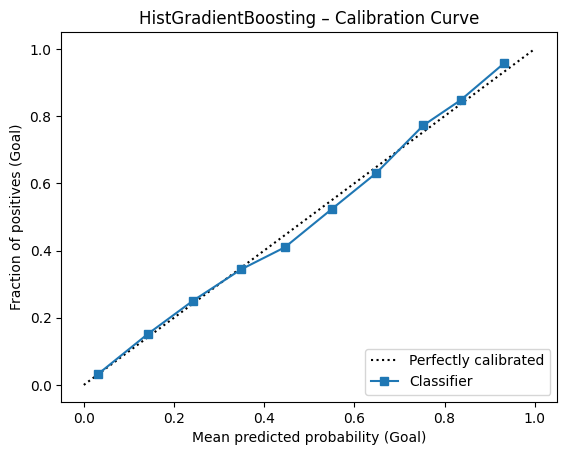

Best F1 threshold: 0.23
Best F1: 0.5050505050505051


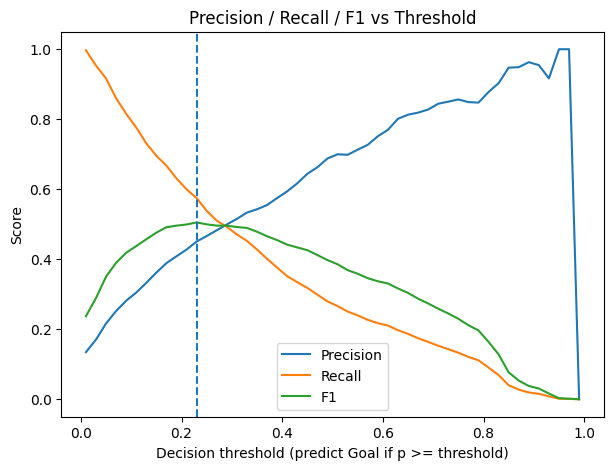

In [12]:
player_group = test_results.groupby(PLAYER_NAME_COL_SAFE)

player_summary = player_group.agg(
    n_shots=("y_true", "count"),
    goals=("y_true", "sum"),
    avg_pred_proba=("proba", "mean"),
).reset_index()

player_summary["empirical_conv_rate"] = player_summary["goals"] / player_summary["n_shots"]
player_summary["model_minus_empirical"] = (
    player_summary["avg_pred_proba"] - player_summary["empirical_conv_rate"]
)

min_shots = 15
player_summary_filtered = player_summary[player_summary["n_shots"] >= min_shots].copy()

print("Players considered (>= 15 shots in test set):", len(player_summary_filtered))

# Over- and under-estimated players
believers = player_summary_filtered.sort_values("model_minus_empirical", ascending=False).head(15)
doubters  = player_summary_filtered.sort_values("model_minus_empirical", ascending=True).head(15)

print("\nTop players model overestimates (believes in too much):")
display(believers)

print("\nTop players model underestimates (doubts too much):")
display(doubters)

# Calibration
brier = brier_score_loss(y_test, y_test_proba)
print("Brier score (lower = better):", brier)

plt.figure(figsize=(6, 5))
CalibrationDisplay.from_predictions(
    y_test,
    y_test_proba,
    n_bins=10,
)
plt.title(f"{best_model_name} – Calibration Curve")
plt.xlabel("Mean predicted probability (Goal)")
plt.ylabel("Fraction of positives (Goal)")
plt.show()

# Threshold sweep
thresholds = np.linspace(0.01, 0.99, 50)
precisions = []
recalls = []
f1s = []

for t in thresholds:
    y_pred_t = (y_test_proba >= t).astype(int)
    precisions.append(precision_score(y_test, y_pred_t, zero_division=0))
    recalls.append(recall_score(y_test, y_pred_t, zero_division=0))
    f1s.append(f1_score(y_test, y_pred_t, zero_division=0))

threshold_df = pd.DataFrame({
    "threshold": thresholds,
    "precision": precisions,
    "recall": recalls,
    "f1": f1s,
})

best_f1_row = threshold_df.iloc[threshold_df["f1"].idxmax()]
print("Best F1 threshold:", best_f1_row["threshold"])
print("Best F1:", best_f1_row["f1"])

plt.figure(figsize=(7, 5))
plt.plot(thresholds, precisions, label="Precision")
plt.plot(thresholds, recalls,   label="Recall")
plt.plot(thresholds, f1s,       label="F1")
plt.axvline(best_f1_row["threshold"], linestyle="--")
plt.xlabel("Decision threshold (predict Goal if p >= threshold)")
plt.ylabel("Score")
plt.title("Precision / Recall / F1 vs Threshold")
plt.legend()
plt.show()


Overestimated player: Alexandre Lacazette shots: 23
Underestimated player: Kylian Mbappé Lottin shots: 47


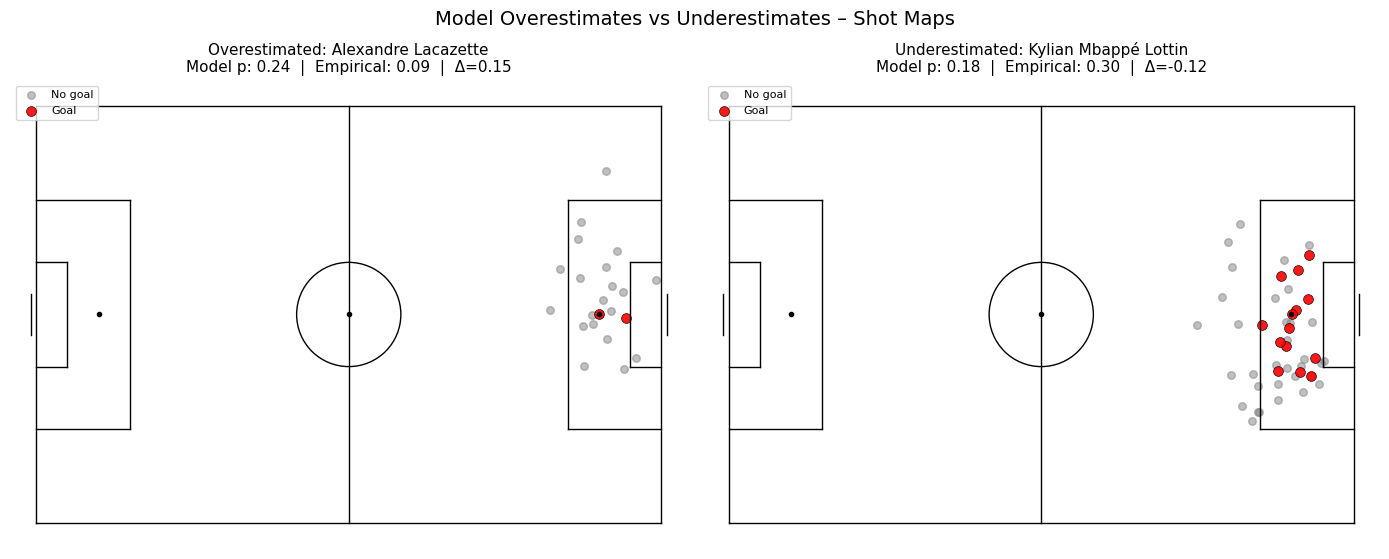

In [13]:
top_believer = believers.iloc[2]
top_doubter  = doubters.iloc[4]

believer_name = top_believer[PLAYER_NAME_COL_SAFE]
doubter_name  = top_doubter[PLAYER_NAME_COL_SAFE]

# All shots for each player in the *test* set
believer_shots = test_results[test_results[PLAYER_NAME_COL_SAFE] == believer_name].copy()
doubter_shots  = test_results[test_results[PLAYER_NAME_COL_SAFE] == doubter_name].copy()

print("Overestimated player:", believer_name, "shots:", len(believer_shots))
print("Underestimated player:", doubter_name, "shots:", len(doubter_shots))

def plot_player_shots_on_pitch(ax, shots_df, title):
    draw_pitch(ax=ax, color="#000000", lw=1)

    # Separate goals and non-goals
    goals = shots_df[shots_df["y_true"] == 1]
    no_goals = shots_df[shots_df["y_true"] == 0]

    # Non-goals
    ax.scatter(
        no_goals["shot_x"],
        no_goals["shot_y"],
        s=30,
        c="gray",
        alpha=0.5,
        label="No goal",
    )

    # Goals
    ax.scatter(
        goals["shot_x"],
        goals["shot_y"],
        s=50,
        c="red",
        alpha=0.9,
        edgecolors="black",
        linewidths=0.5,
        label="Goal",
    )

    ax.set_title(title, fontsize=11)
    ax.legend(loc="upper left", fontsize=8)

believer_title = (
    f"Overestimated: {believer_name}\n"
    f"Model p: {top_believer['avg_pred_proba']:.2f}  |  "
    f"Empirical: {top_believer['empirical_conv_rate']:.2f}  |  "
    f"Δ={top_believer['model_minus_empirical']:.2f}"
)

doubter_title = (
    f"Underestimated: {doubter_name}\n"
    f"Model p: {top_doubter['avg_pred_proba']:.2f}  |  "
    f"Empirical: {top_doubter['empirical_conv_rate']:.2f}  |  "
    f"Δ={top_doubter['model_minus_empirical']:.2f}"
)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

plot_player_shots_on_pitch(axes[0], believer_shots, believer_title)
plot_player_shots_on_pitch(axes[1], doubter_shots, doubter_title)

plt.suptitle("Model Overestimates vs Underestimates – Shot Maps", fontsize=14)
plt.tight_layout()
plt.show()


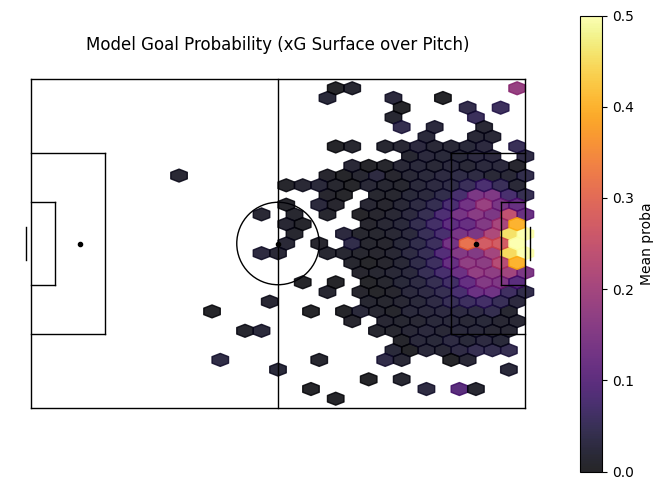

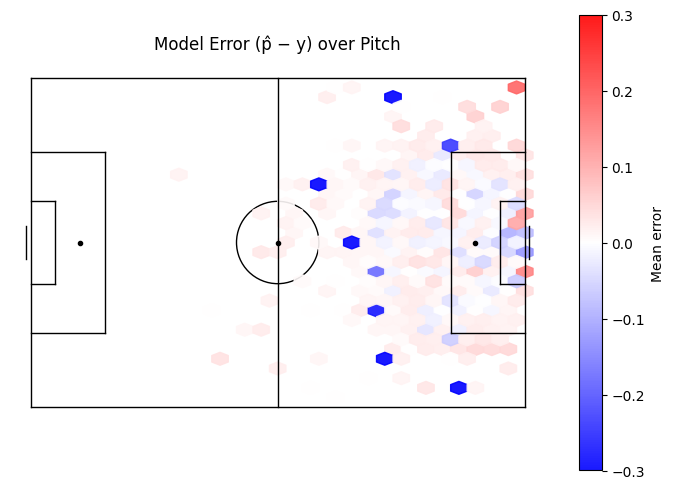

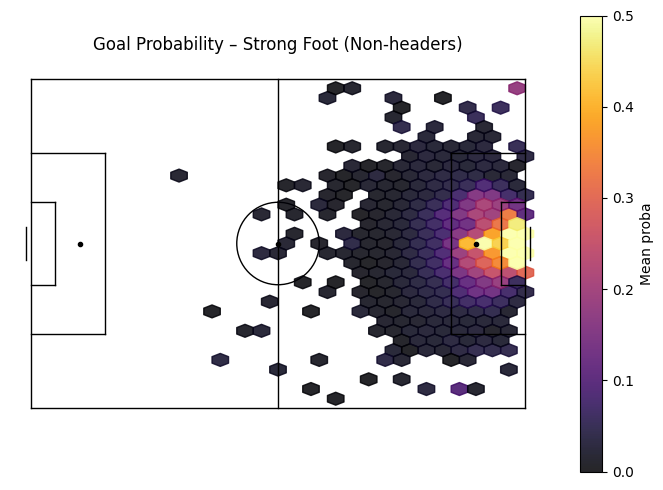

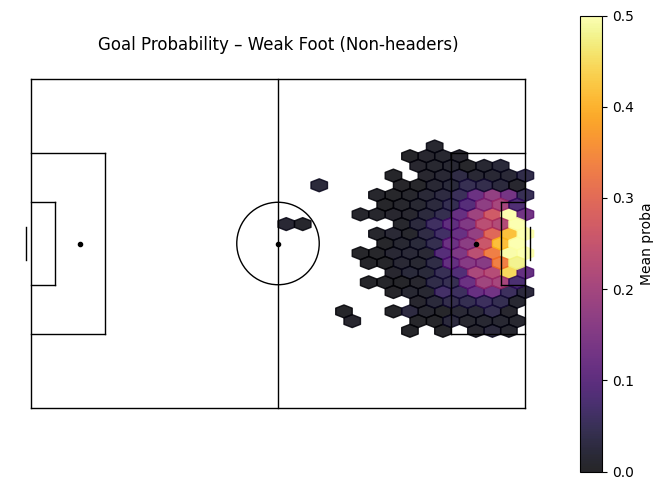

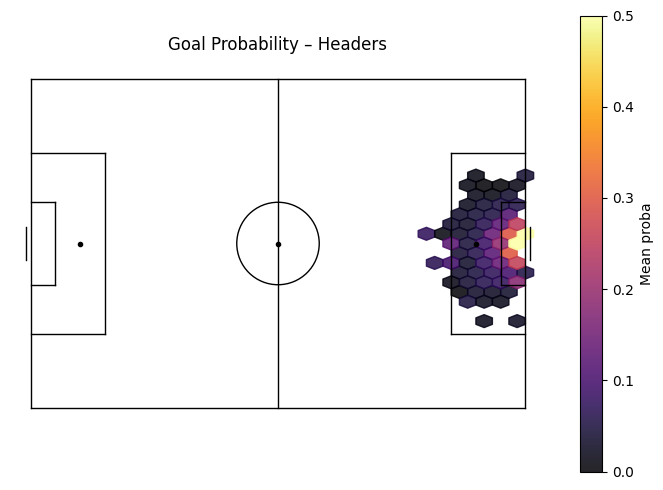

/tmp/ipython-input-253705692.py:112: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


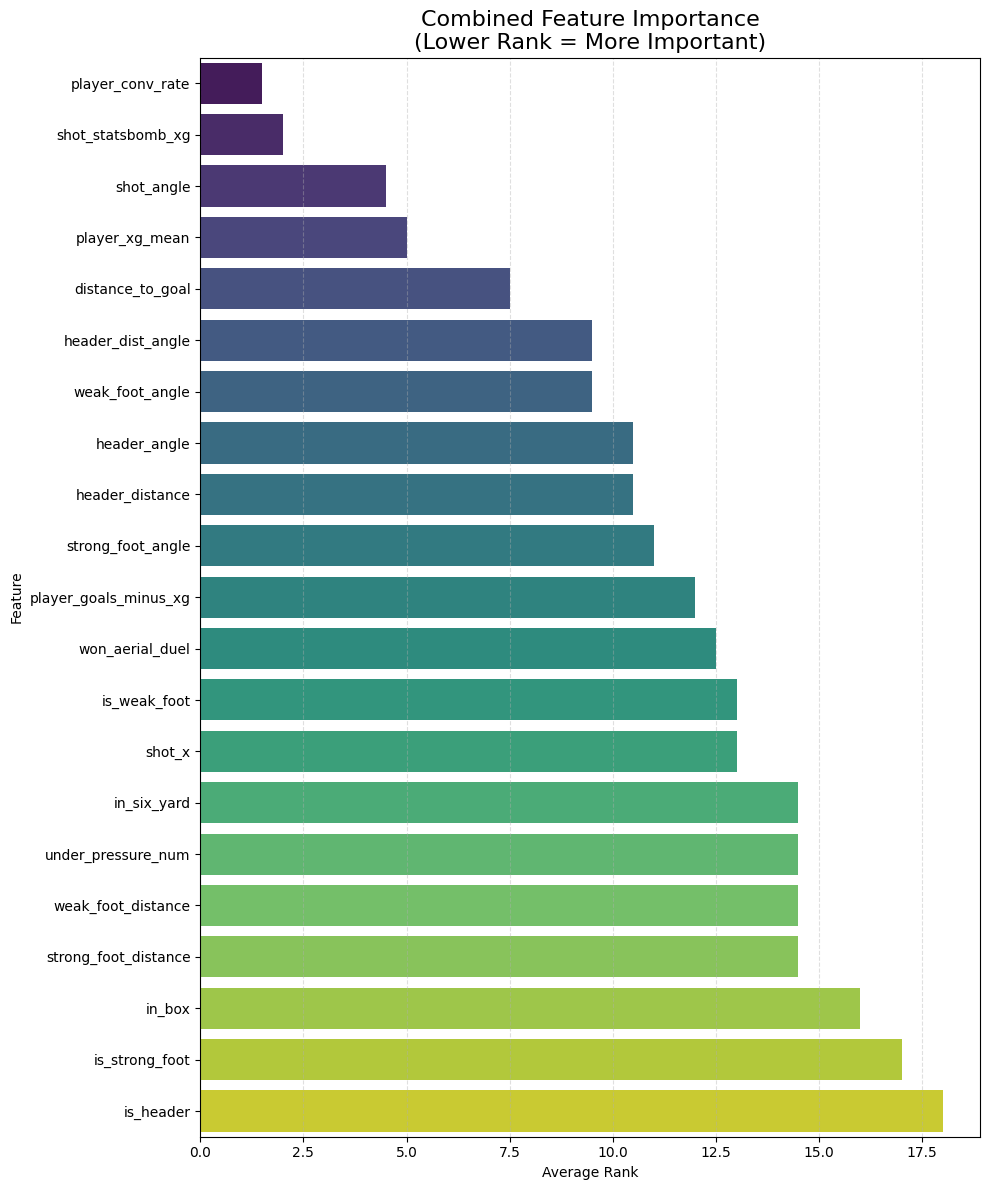

/tmp/ipython-input-253705692.py:128: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


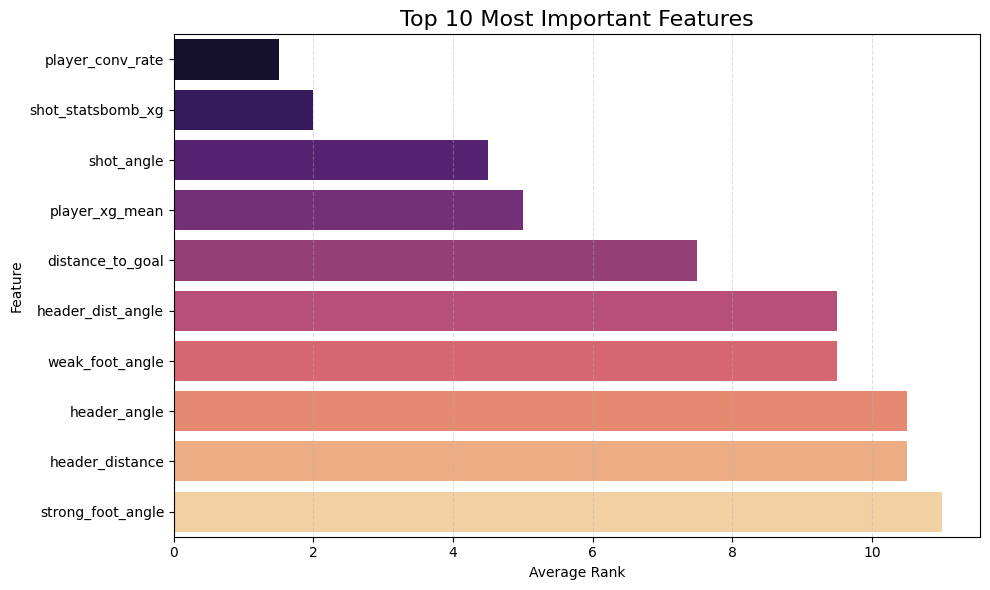

In [14]:
def plot_pitch_hex(
    df,
    title="",
    value_col=None,
    aggfunc="mean",
    cmap="viridis",
    gridsize=30,
    vmin=None,
    vmax=None,
    alpha=0.9,
    line_color="#000000",
    lw=1,
):
    df = df.dropna(subset=["shot_x", "shot_y"]).copy()
    x = df["shot_x"].values
    y = df["shot_y"].values

    fig, ax = plt.subplots(figsize=(7, 5))
    draw_pitch(ax=ax, color=line_color, lw=lw)

    if value_col is None:
        hb = ax.hexbin(
            x, y,
            gridsize=gridsize,
            extent=(PITCH_X_MIN, PITCH_X_MAX, PITCH_Y_MIN, PITCH_Y_MAX),
            cmap=cmap,
            alpha=alpha,
        )
        cbar_label = "Shot count"
    else:
        vals = df[value_col].values
        reducer = np.mean if aggfunc == "mean" else np.sum
        cbar_label = f"{aggfunc.capitalize()} {value_col}"

        hb = ax.hexbin(
            x, y,
            C=vals,
            reduce_C_function=reducer,
            gridsize=gridsize,
            extent=(PITCH_X_MIN, PITCH_X_MAX, PITCH_Y_MIN, PITCH_Y_MAX),
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            alpha=alpha,
        )

    fig.colorbar(hb, ax=ax, label=cbar_label)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()


def plot_goal_probability_map(df, title="Goal Probability by Location", vmax=0.5):
    plot_pitch_hex(
        df,
        title=title,
        value_col="proba",
        aggfunc="mean",
        cmap="inferno",
        gridsize=30,
        vmin=0.0,
        vmax=vmax,
        alpha=0.85,
    )

# xG surface
plot_goal_probability_map(
    test_results,
    title="Model Goal Probability (xG Surface over Pitch)",
    vmax=0.5,
)

# Error surface
plot_pitch_hex(
    test_results,
    title="Model Error (p̂ − y) over Pitch",
    value_col="error",
    aggfunc="mean",
    cmap="bwr",
    vmin=-0.3,
    vmax=0.3,
)

sub = test_results.dropna(subset=["shot_x", "shot_y"]).copy()
mask_header_sub      = sub["is_header"] == 1
mask_non_header_sub  = sub["is_header"] == 0
mask_strong_foot_sub = sub["is_strong_foot"] == 1
mask_weak_foot_sub   = sub["is_weak_foot"] == 1

plot_goal_probability_map(
    sub[mask_strong_foot_sub & mask_non_header_sub],
    title="Goal Probability – Strong Foot (Non-headers)",
    vmax=0.5,
)

plot_goal_probability_map(
    sub[mask_weak_foot_sub & mask_non_header_sub],
    title="Goal Probability – Weak Foot (Non-headers)",
    vmax=0.5,
)

plot_goal_probability_map(
    sub[mask_header_sub],
    title="Goal Probability – Headers",
    vmax=0.5,
)

# Combined feature importance plots
viz = importance_df.sort_values("average_rank").copy()

plt.figure(figsize=(10, 12))
sns.barplot(
    data=viz,
    x="average_rank",
    y=viz.index,
    palette="viridis",
)
plt.title("Combined Feature Importance\n(Lower Rank = More Important)", fontsize=16)
plt.xlabel("Average Rank")
plt.ylabel("Feature")
plt.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

top10 = importance_df.sort_values("average_rank").head(10)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top10,
    x="average_rank",
    y=top10.index,
    palette="magma",
)
plt.title("Top 10 Most Important Features", fontsize=16)
plt.xlabel("Average Rank")
plt.ylabel("Feature")
plt.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()
